Logistic Regression

Task 1: Data Exploration (EDA)

1(a) Load the dataset and basic EDA

In [1]:
import pandas as pd
import numpy as np
# Load data
train = pd.read_csv('Titanic_train.csv')
test = pd.read_csv('Titanic_test.csv')
print("Train shape:", train.shape)
print("Test shape:", test.shape)
# Look at first few rows
train.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Basic info about columns and data types
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Summary statistics for numeric and categorical columns
train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [4]:
# Target variable distribution
train['Survived'].value_counts()
train['Survived'].value_counts(normalize=True)  # in percentages

,proportion
Survived,
0,0.616162
1,0.383838


In [5]:
# Check missing values
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


1(b) Visualizations – histograms, box plots, correlations

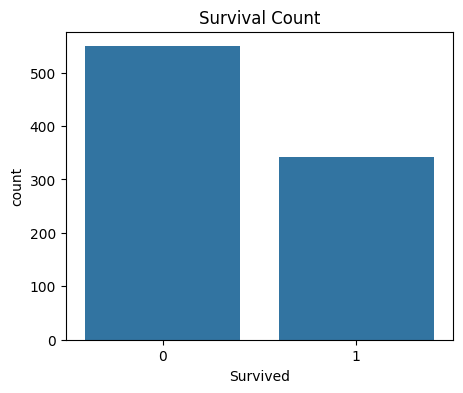

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
# 1. Count of Survived
plt.figure(figsize=(5,4))
sns.countplot(x='Survived', data=train)
plt.title('Survival Count')
plt.show()

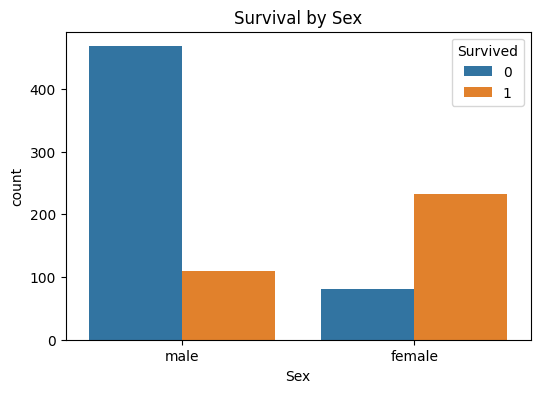

In [7]:
# 2. Survival by Sex
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title('Survival by Sex')
plt.show()

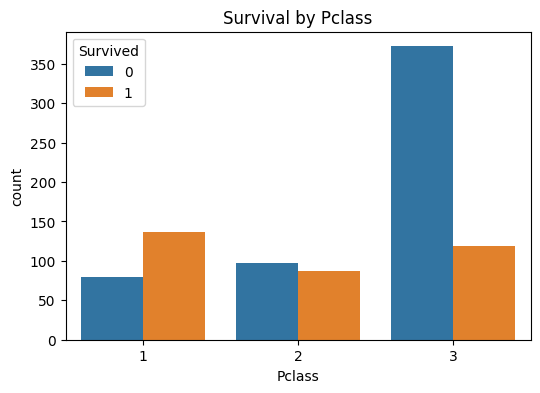

In [8]:
# 3. Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=train)
plt.title('Survival by Pclass')
plt.show()

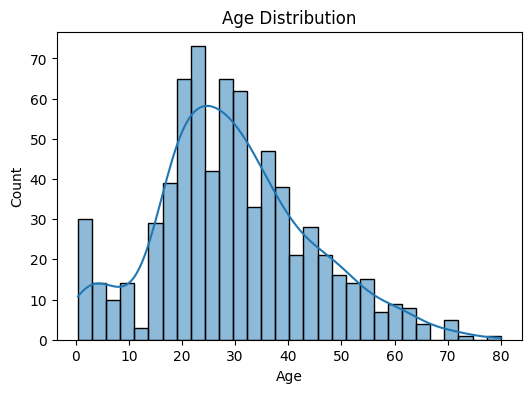

In [9]:
# 4. Histogram of Age
plt.figure(figsize=(6,4))
sns.histplot(train['Age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

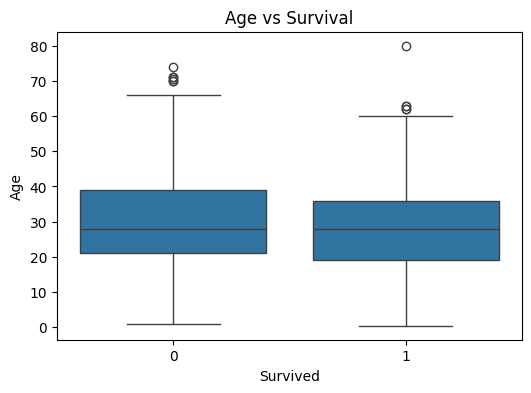

In [10]:
# 5. Boxplot of Age vs Survived
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=train)
plt.title('Age vs Survival')
plt.show()

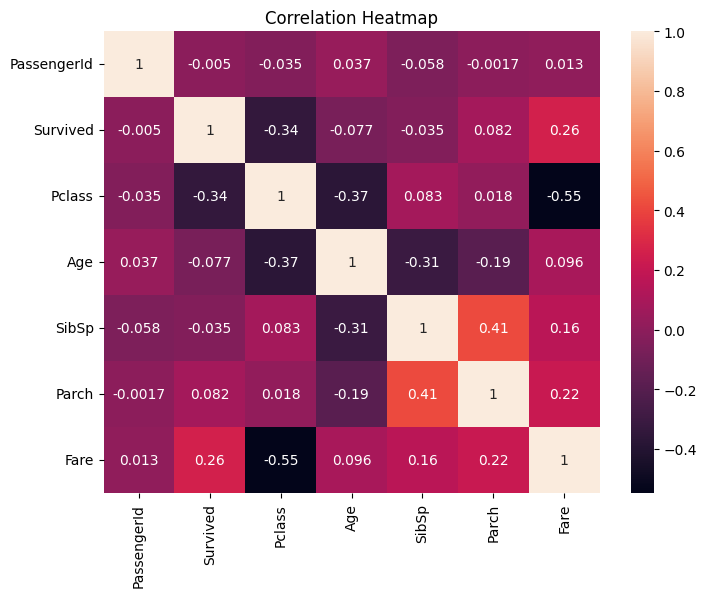

In [11]:
# 6. Correlation heatmap for numeric variables
plt.figure(figsize=(8,6))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

Task 2: Data Preprocessing

2(a) Handle missing values

In [12]:
# Work on both train and test together to keep same preprocessing
full_data = [train, test]
for dataset in full_data:
    # Age: fill missing with median
    dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
    # Embarked: fill missing with mode (most common value)
    dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace=True)
    # Fare: if any missing, fill with median
    dataset['Fare'].fillna(dataset['Fare'].median(), inplace=True)
    # Drop Cabin (too many missing) and Ticket, Name for simplicity
    dataset.drop(['Cabin', 'Ticket', 'Name'], axis=1, inplace=True)
# Check that missing values are handled
train.isnull().sum()

/tmp/ipython-input-42098329.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
/tmp/ipython-input-42098329.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


2(b) Encode categorical variables

In [13]:
for dataset in full_data:
    dataset['Sex'] = dataset['Sex'].map({'male': 0, 'female': 1})
    # One-hot encode Embarked
    embarked_dummies = pd.get_dummies(dataset['Embarked'], prefix='Embarked')
    dataset[embarked_dummies.columns] = embarked_dummies
    # Drop original Embarked
    dataset.drop('Embarked', axis=1, inplace=True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,False,False,True
1,2,1,1,1,38.0,1,0,71.2833,True,False,False
2,3,1,3,1,26.0,0,0,7.9250,False,False,True
3,4,1,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,0,35.0,0,0,8.0500,False,False,True


Task 3: Model Building – Logistic Regression

3(a) Prepare data and split

In [14]:
from sklearn.model_selection import train_test_split
# Features: drop Survived and PassengerId from train
X = train.drop(['Survived', 'PassengerId'], axis=1)
y = train['Survived']
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (712, 9)
X_test shape: (179, 9)


3(b) Build and train logistic regression model

In [15]:
from sklearn.linear_model import LogisticRegression
# Create model
log_reg = LogisticRegression(max_iter=1000)
# Train the model
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Task 4: Model Evaluation

4(a) Compute metrics

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
# Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244
ROC-AUC  : 0.8444

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



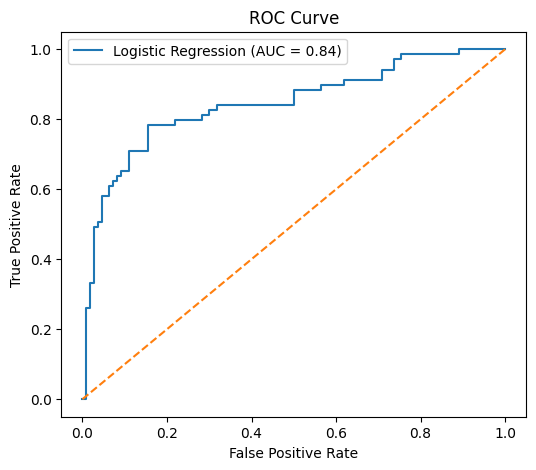

In [17]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Task 5: Interpretation of the Logistic Regression Model

5(a) Coefficients

In [18]:
# Coefficients with feature names
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
coef_df

,Feature,Coefficient
1,Sex,2.559667
7,Embarked_Q,0.313741
6,Embarked_C,0.043967
5,Fare,0.002225
2,Age,-0.038587
4,Parch,-0.071593
3,SibSp,-0.243688
8,Embarked_S,-0.342004
0,Pclass,-1.091916


5(b) Significance of features

From the signs and sizes:

Sex (big positive): Being female (Sex=1) strongly increases the chance of survival.

Pclass (large negative): Higher Pclass value means lower class (3rd class). The negative coefficient means 3rd class passengers have lower chance of survival than 1st class.

Fare (small positive): Higher fare slightly increases survival; richer passengers tend to survive more.

Age (small negative): As age increases, survival probability slightly decreases. Younger passengers do a bit better.

SibSp and Parch (negative): Having more family members on board often slightly reduces survival in this simple model (maybe harder to escape).

Embarked: Compared to one of the ports, some ports like Q have a small positive effect.

Simple conclusion:

The most important features in this simple model are Sex and Pclass, followed by Fare and Age.

In short: women, higher class, younger age, and higher fares are associated with a higher survival probability.

Interview Questions:

Q1. What is the difference between precision and recall?


Precision

Precision tells you how accurate your positive predictions are.

In other words:

Out of all the passengers the model predicted as “survived”, how many really survived?

If the model wrongly predicts many people as survivors (when they didn’t survive), then precision becomes low.

Recall

Recall tells you how many of the actual survivors the model was able to correctly identify.

In other words:

Out of all the passengers who actually survived, how many did the model correctly predict as survivors?

If the model misses many real survivors, recall becomes low.

Q2. What is cross-validation, and why is it important in binary classification?

What is cross-validation?

Cross-validation is a method where the dataset is split into several small parts called “folds”.
The model is trained on some of the folds and tested on the remaining fold.
This process is repeated several times so that every part of the data gets a chance to be tested.

Why is it important?

Gives more reliable accuracy
One train-test split may give a lucky or unlucky score.
Cross-validation gives an average score which is more stable.

Helps prevent overfitting
The model is tested on multiple different parts of the data, so it learns to generalize better.

Uses data more efficiently
Every row in the dataset is used for both training and testing at different times.

Very useful in binary classification
Especially when one class is smaller than the other (like “survived” vs. “not survived”),
cross-validation ensures the model is judged fairly.